In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from data_utils import load_dataset, compute_rul_cusum, HEALTHY_FRAC
from config import FEATURES_TRAIN

plt.rcParams['figure.dpi'] = 140
COND_COLOR = {1: '#1565C0', 2: '#2E7D32', 3: '#BF360C'}
COND_LABEL = {
    1: 'Koşul 1 — 1800 rpm / 4000 N',
    2: 'Koşul 2 — 1650 rpm / 4200 N',
    3: 'Koşul 3 — 1500 rpm / 5000 N',
}
print('Importlar tamam.')

Importlar tamam.


In [2]:
print('Dataset yükleniyor...')
dataset = load_dataset(split='learning')
print(f'Tamam: {list(dataset.keys())}')

Dataset yükleniyor...


Tamam: ['Bearing1_1', 'Bearing1_2', 'Bearing2_1', 'Bearing2_2', 'Bearing3_1', 'Bearing3_2']


In [3]:
print('CSV okunuyor...')
df_feat = pd.read_csv(FEATURES_TRAIN)
print(f'Tamam: {df_feat.shape}')

CSV okunuyor...


Tamam: (7534, 63)


In [4]:
bearings = sorted(dataset.keys())
print('CUSUM hesaplanıyor...')
results = {}
for b in bearings:
    print(f'  {b}...')
    results[b] = compute_rul_cusum(dataset[b], split='learning')
    print(f'  {b} tamam.')
print('Hazır.')

CUSUM hesaplanıyor...
  Bearing1_1...


  Bearing1_1 tamam.
  Bearing1_2...
  Bearing1_2 tamam.
  Bearing2_1...
  Bearing2_1 tamam.
  Bearing2_2...
  Bearing2_2 tamam.
  Bearing3_1...
  [Bearing3_1] Cond3 min cap: 3.2 → 20.0 dk
  Bearing3_1 tamam.
  Bearing3_2...


  Bearing3_2 tamam.
Hazır.


## Grafik 1 — Ham RMS: 6 Bearing Yan Yana

Kaydedildi: ../experiments/results/cusum_raw_rms.png


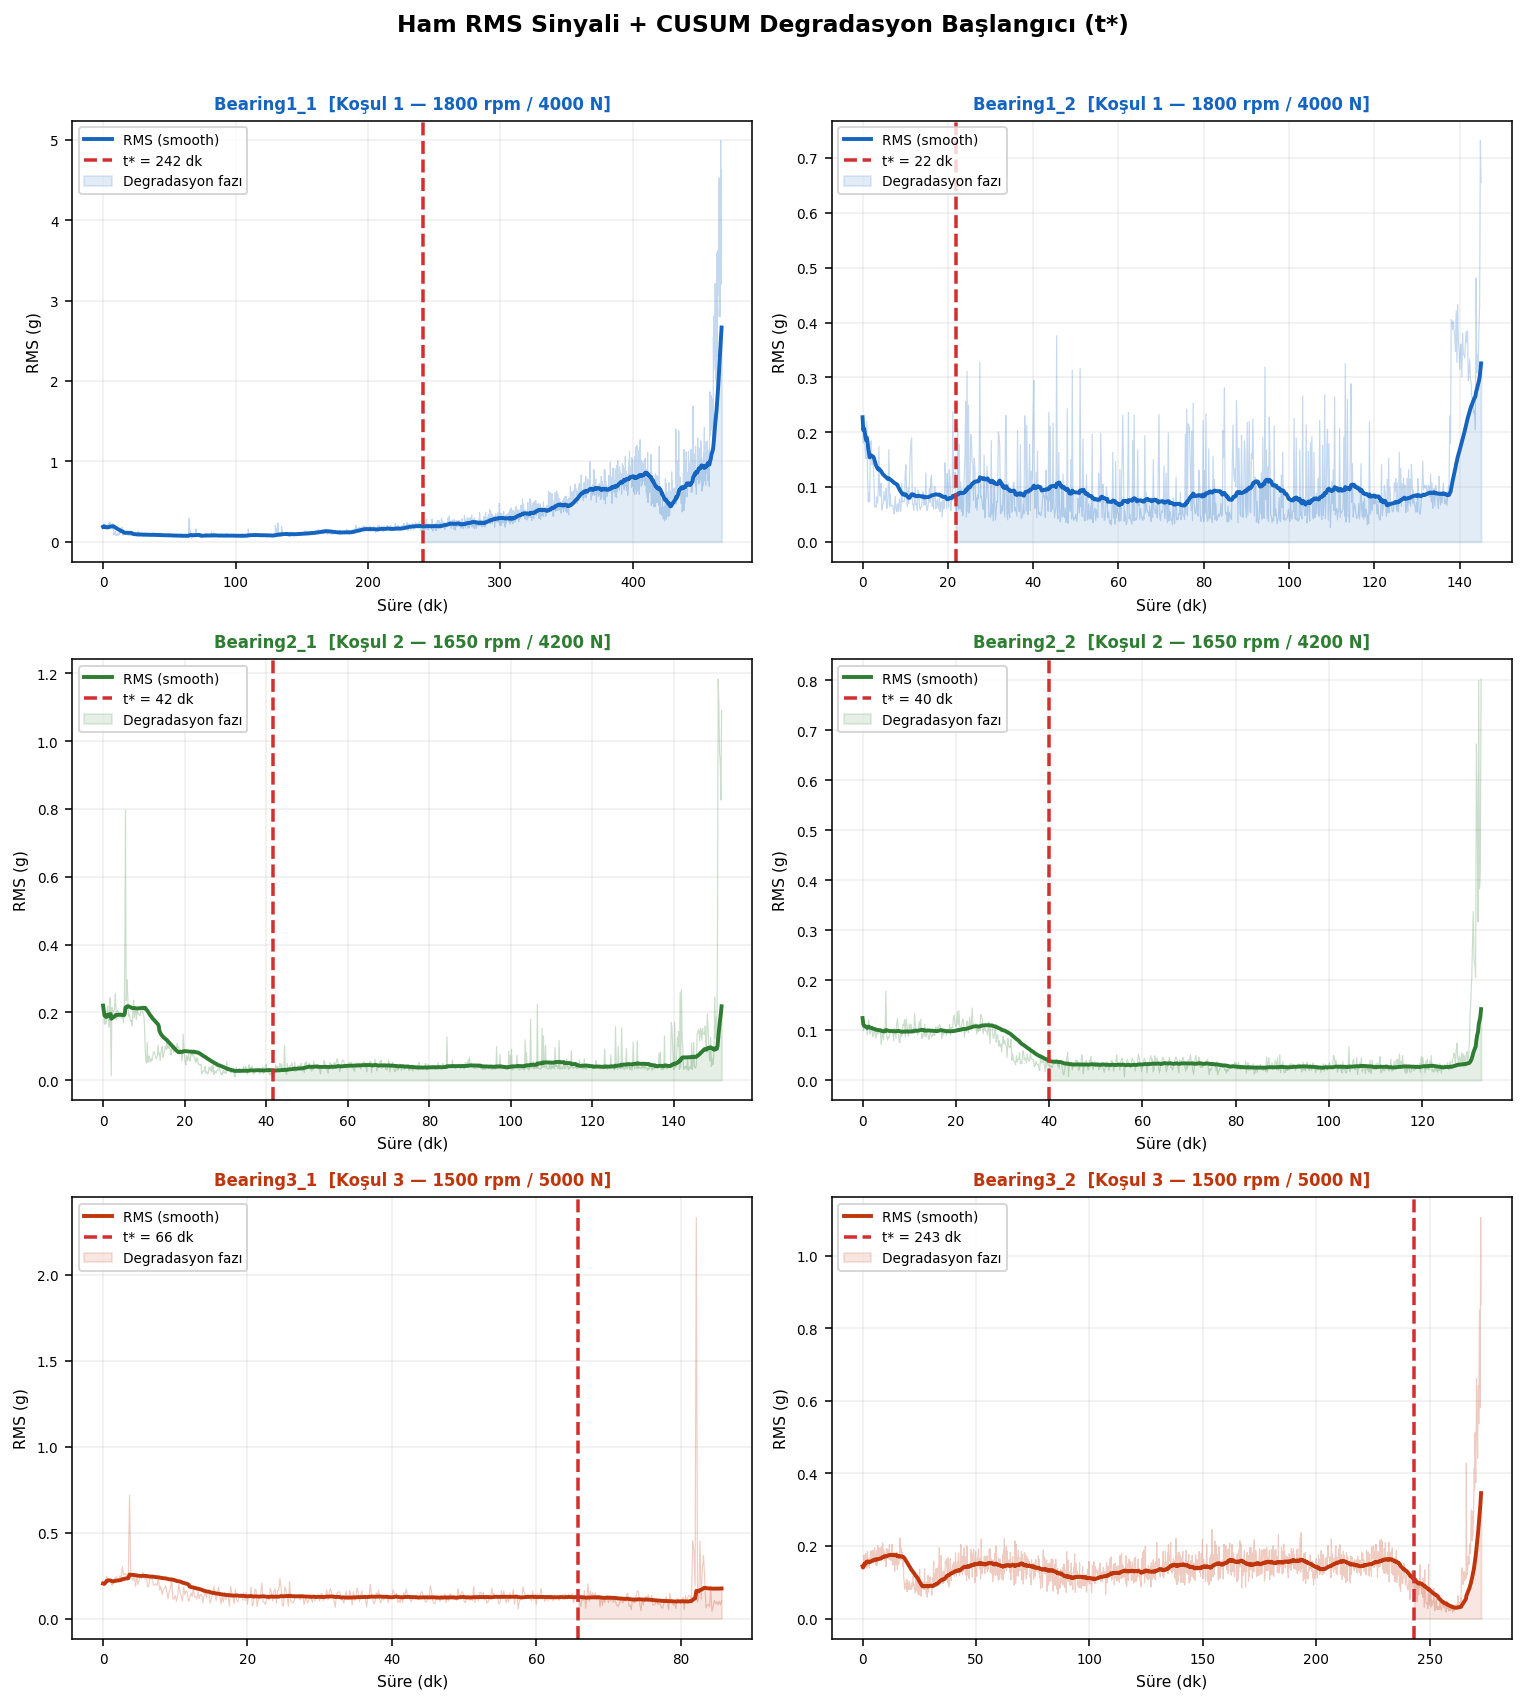

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12))
axes = axes.flatten()

for ax, bname in zip(axes, bearings):
    cond  = int(bname[7])
    color = COND_COLOR[cond]
    bdf   = df_feat[df_feat['bearing'] == bname].sort_values('time_s')
    t_min = bdf['time_s'].values / 60
    rms   = bdf['h_rms'].values
    t_star_m = results[bname]['t_star_s'] / 60

    # Ham sinyal ince, smoothed kalın
    smoothed = pd.Series(rms).rolling(50, min_periods=1).mean().values
    ax.plot(t_min, rms,      color=color, lw=0.6, alpha=0.25)
    ax.plot(t_min, smoothed, color=color, lw=2.0, label='RMS (smooth)')
    ax.axvline(t_star_m, color='#D32F2F', lw=1.8,
               linestyle='--', label=f't* = {t_star_m:.0f} dk')
    ax.fill_between(t_min, smoothed,
                    where=(t_min >= t_star_m),
                    alpha=0.12, color=color, label='Degradasyon fazı')

    ax.set_title(f'{bname}  [{COND_LABEL[cond]}]',
                 fontsize=8.5, fontweight='bold', color=color)
    ax.set_xlabel('Süre (dk)', fontsize=8)
    ax.set_ylabel('RMS (g)', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle('Ham RMS Sinyali + CUSUM Degradasyon Başlangıcı (t*)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()

import os
os.makedirs('../experiments/results', exist_ok=True)
plt.savefig('../experiments/results/cusum_raw_rms.png', bbox_inches='tight', dpi=150)
print('Kaydedildi: ../experiments/results/cusum_raw_rms.png')
plt.show()



## Grafik 2 — Composite HI: 6 Bearing Yan Yana

Kaydedildi: ../experiments/results/cusum_composite_hi.png


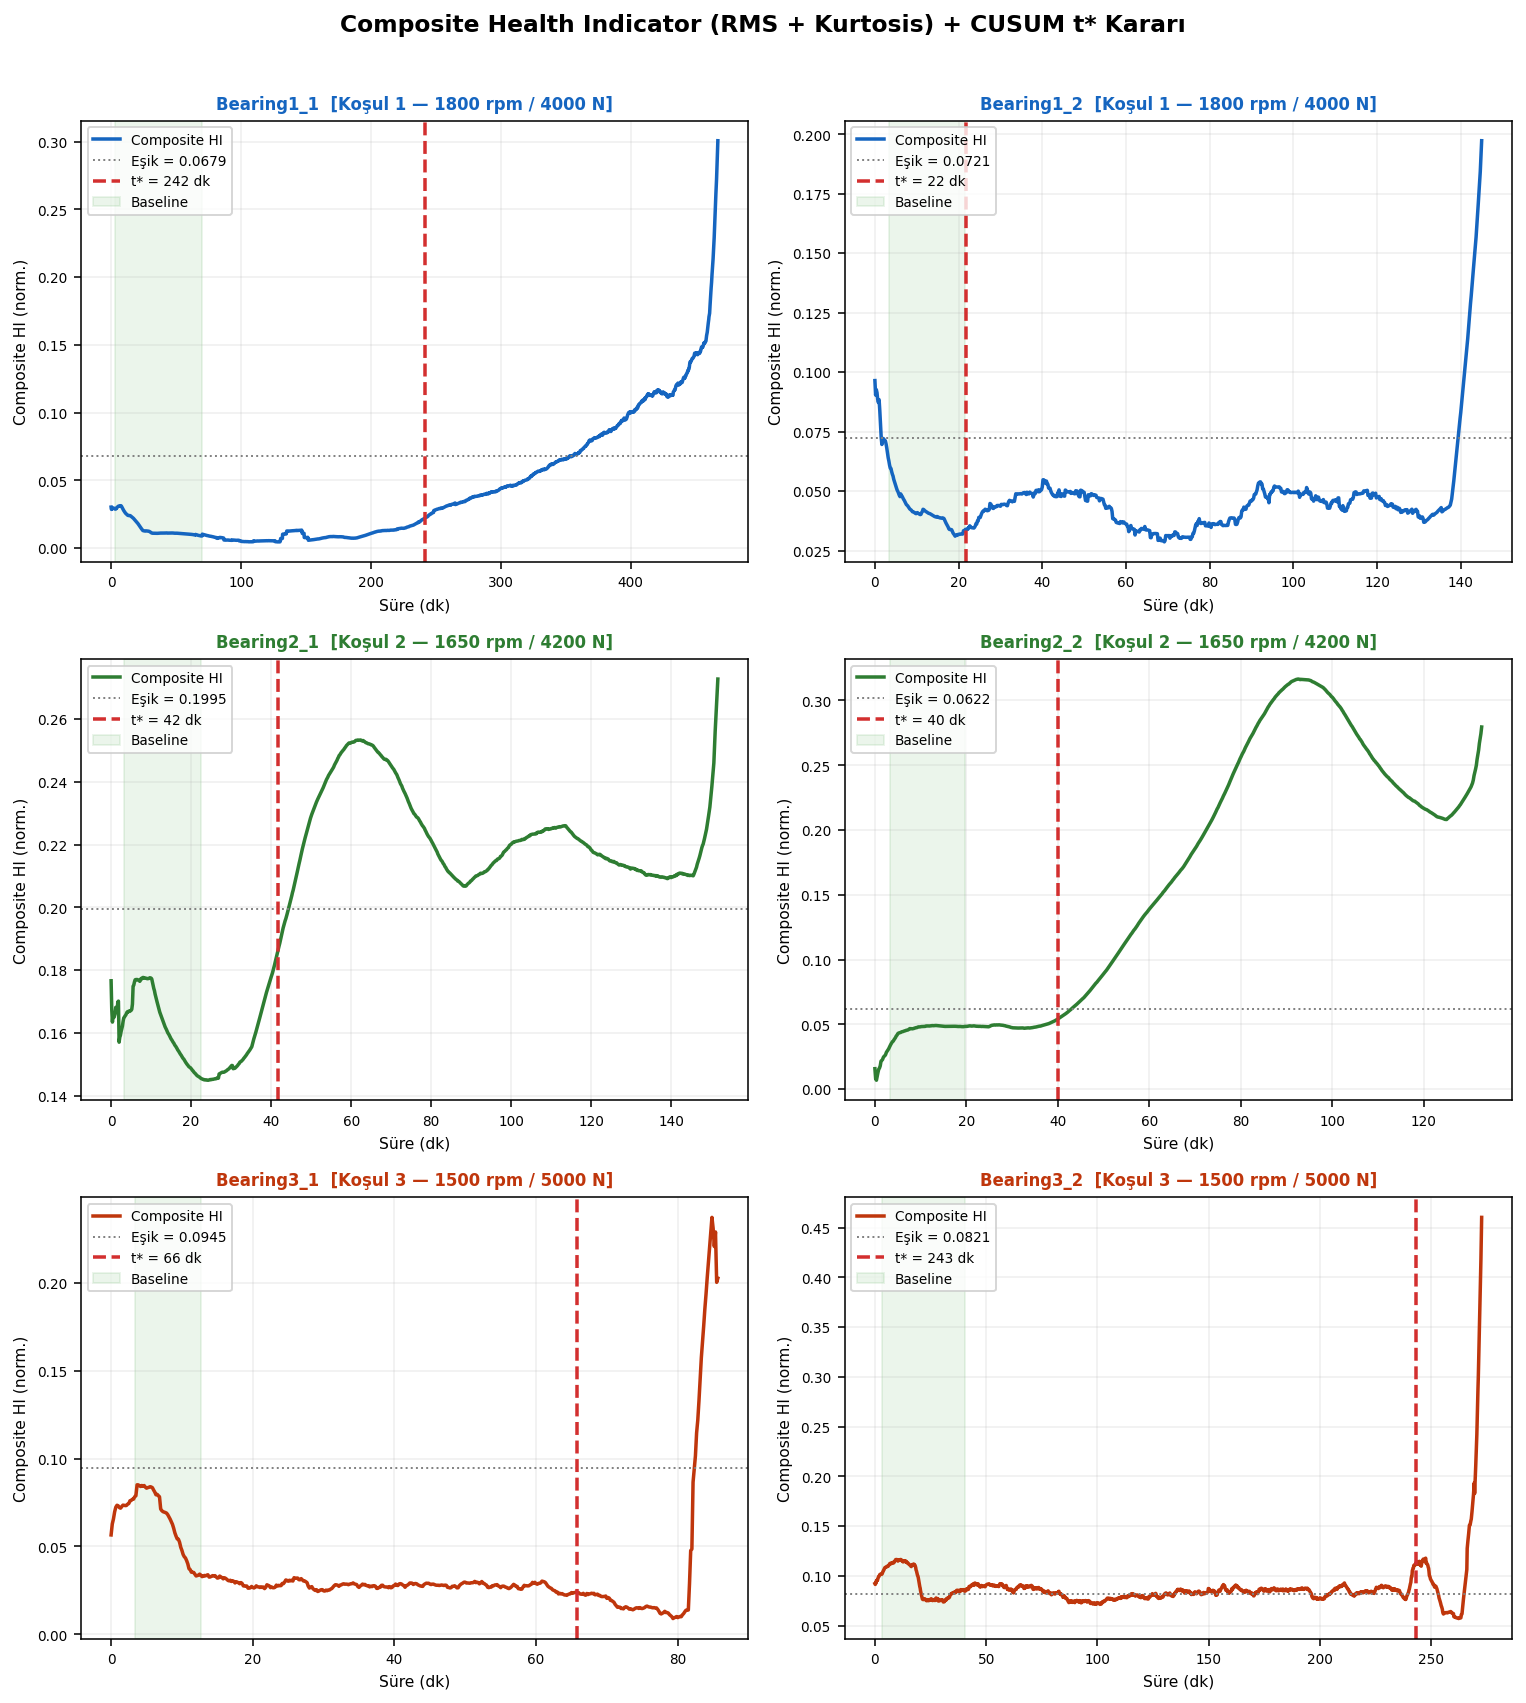

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12))
axes = axes.flatten()

for ax, bname in zip(axes, bearings):
    cond     = int(bname[7])
    color    = COND_COLOR[cond]
    res      = results[bname]
    t_min    = dataset[bname]['times'] / 60
    hi       = res['hi']
    t_star_m = res['t_star_s'] / 60

    # Threshold hesapla
    n         = len(hi)
    n_healthy = max(int(n * HEALTHY_FRAC), 50)
    burn_in   = 20
    std_h     = max(float(np.std(hi[burn_in:n_healthy])), 1e-6)
    h_mult    = {1: 10.0, 2: 18.0, 3: 5.0}[cond]
    threshold = h_mult * std_h

    ax.plot(t_min, hi, color=color, lw=1.8, label='Composite HI')
    ax.axhline(threshold, color='gray', lw=1,
               linestyle=':', label=f'Eşik = {threshold:.4f}')
    ax.axvline(t_star_m, color='#D32F2F', lw=1.8,
               linestyle='--', label=f't* = {t_star_m:.0f} dk')

    # Sağlıklı baseline bölgesi
    ax.axvspan(t_min[burn_in], t_min[n_healthy-1],
               alpha=0.08, color='green', label='Baseline')

    ax.set_title(f'{bname}  [{COND_LABEL[cond]}]',
                 fontsize=8.5, fontweight='bold', color=color)
    ax.set_xlabel('Süre (dk)', fontsize=8)
    ax.set_ylabel('Composite HI (norm.)', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle('Composite Health Indicator (RMS + Kurtosis) + CUSUM t* Kararı',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()

import os
os.makedirs('../experiments/results', exist_ok=True)
plt.savefig('../experiments/results/cusum_composite_hi.png', bbox_inches='tight', dpi=150)
print('Kaydedildi: ../experiments/results/cusum_composite_hi.png')
plt.show()



## Grafik 3 — RUL Etiketleri: 6 Bearing Yan Yana

Kaydedildi: ../experiments/results/cusum_piecewise_rul.png


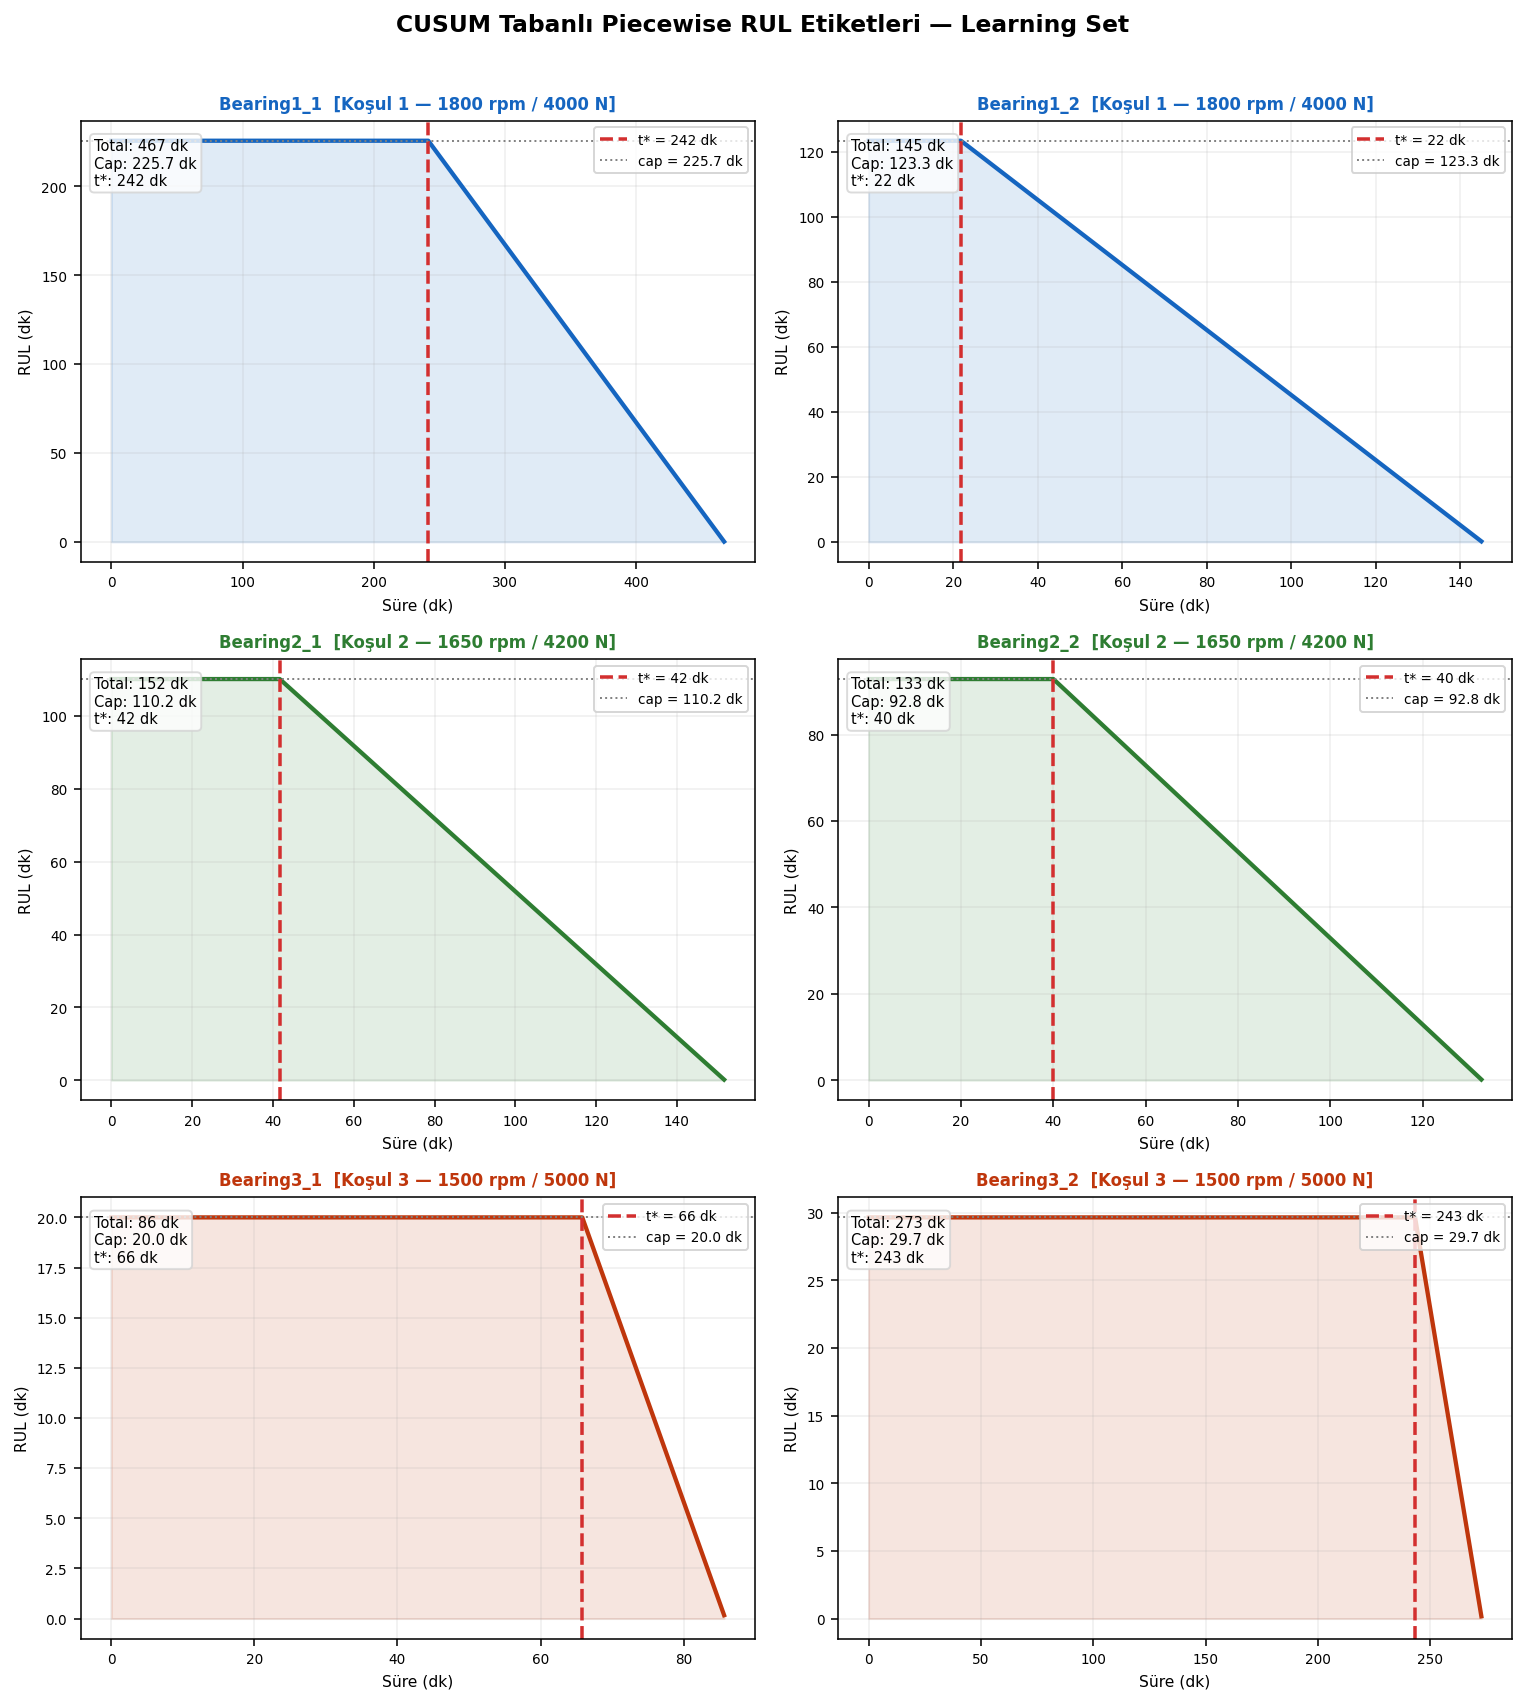

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12))
axes = axes.flatten()

for ax, bname in zip(axes, bearings):
    cond     = int(bname[7])
    color    = COND_COLOR[cond]
    res      = results[bname]
    t_min    = dataset[bname]['times'] / 60
    rul_min  = res['rul_min']
    t_star_m = res['t_star_s'] / 60
    cap_m    = res['cap_s'] / 60
    total_m  = res['total_life_s'] / 60

    ax.plot(t_min, rul_min, color=color, lw=2.2)
    ax.fill_between(t_min, rul_min, alpha=0.13, color=color)
    ax.axvline(t_star_m, color='#D32F2F', lw=1.8,
               linestyle='--', label=f't* = {t_star_m:.0f} dk')
    ax.axhline(cap_m, color='gray', lw=1,
               linestyle=':', label=f'cap = {cap_m:.1f} dk')

    # Notlar
    ax.text(0.02, 0.96,
            f'Total: {total_m:.0f} dk\nCap: {cap_m:.1f} dk\nt*: {t_star_m:.0f} dk',
            transform=ax.transAxes, fontsize=7.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='lightgray', alpha=0.8))

    ax.set_title(f'{bname}  [{COND_LABEL[cond]}]',
                 fontsize=8.5, fontweight='bold', color=color)
    ax.set_xlabel('Süre (dk)', fontsize=8)
    ax.set_ylabel('RUL (dk)', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle('CUSUM Tabanlı Piecewise RUL Etiketleri — Learning Set',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()

import os
os.makedirs('../experiments/results', exist_ok=True)
plt.savefig('../experiments/results/cusum_piecewise_rul.png', bbox_inches='tight', dpi=150)
print('Kaydedildi: ../experiments/results/cusum_piecewise_rul.png')
plt.show()



## Grafik 4 — Koşula Göre RUL (Normalize Zaman)

Kaydedildi: ../experiments/results/cusum_normalized_rul.png


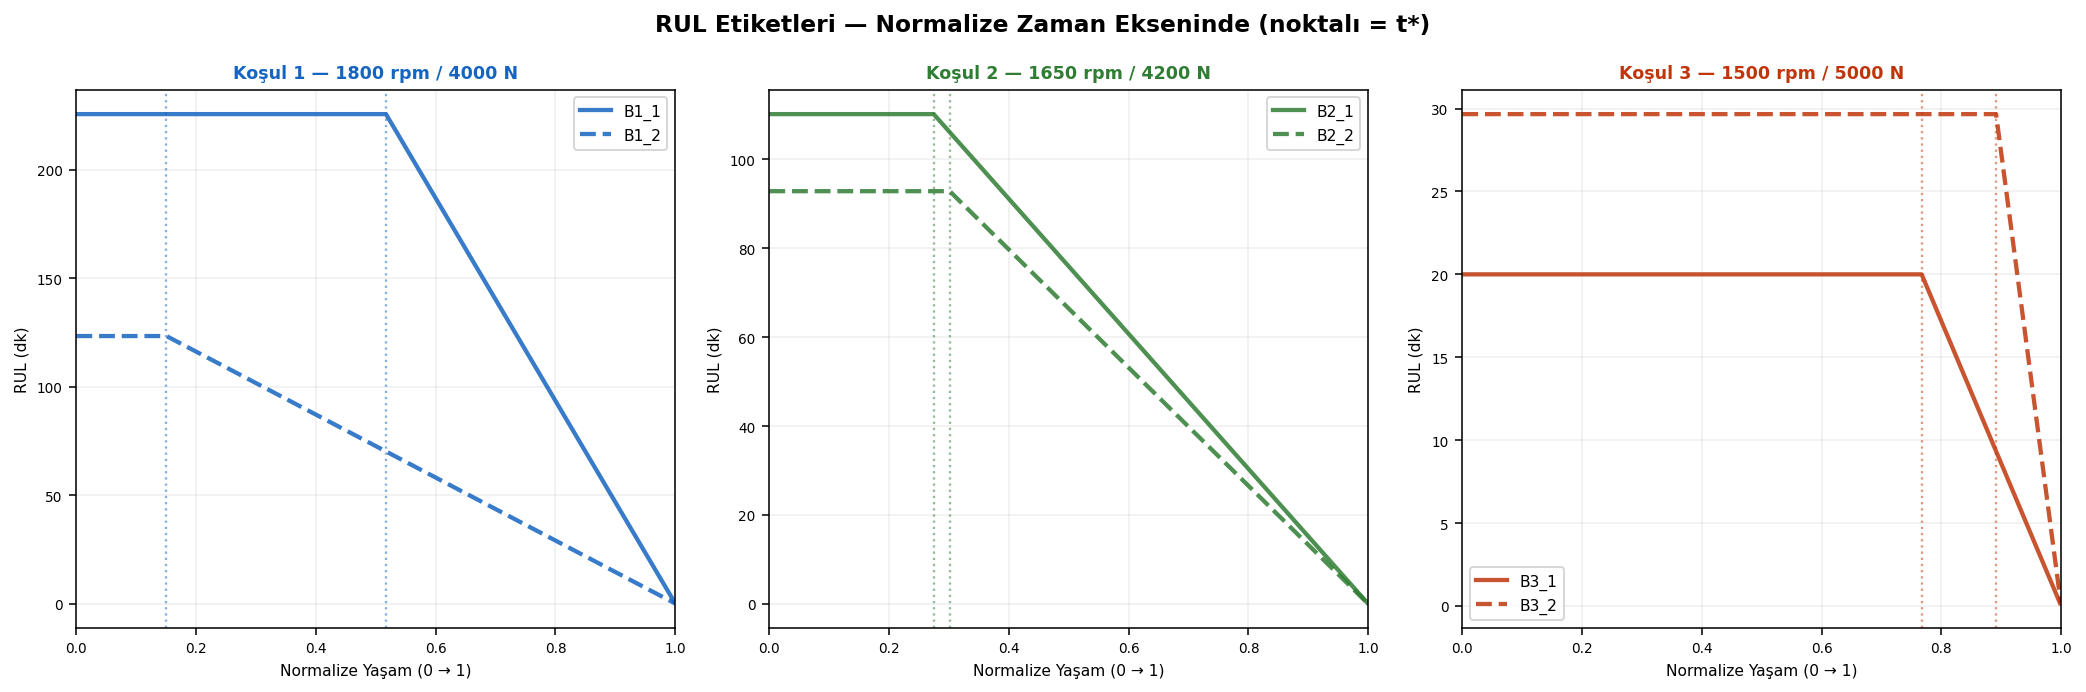

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for cond in [1, 2, 3]:
    ax = axes[cond - 1]
    color = COND_COLOR[cond]
    cond_bearings = [b for b in bearings if int(b[7]) == cond]

    for i, bname in enumerate(cond_bearings):
        res    = results[bname]
        times  = dataset[bname]['times']
        t_norm = times / (times[-1] + 10)
        style  = '-' if i == 0 else '--'
        label  = bname.replace('Bearing', 'B')

        ax.plot(t_norm, res['rul_min'],
                lw=2.2, linestyle=style,
                color=color, label=label, alpha=0.85)

        t_star_norm = res['t_star_s'] / (times[-1] + 10)
        ax.axvline(t_star_norm, lw=1.2, linestyle=':',
                   color=color, alpha=0.5)

    ax.set_title(COND_LABEL[cond], fontsize=9,
                 fontweight='bold', color=color)
    ax.set_xlabel('Normalize Yaşam (0 → 1)', fontsize=8)
    ax.set_ylabel('RUL (dk)', fontsize=8)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, 1)

plt.suptitle('RUL Etiketleri — Normalize Zaman Ekseninde (noktalı = t*)',
             fontsize=12, fontweight='bold')
plt.tight_layout()

import os
os.makedirs('../experiments/results', exist_ok=True)
plt.savefig('../experiments/results/cusum_normalized_rul.png', bbox_inches='tight', dpi=150)
print('Kaydedildi: ../experiments/results/cusum_normalized_rul.png')
plt.show()


## Özet Tablo

In [9]:
rows = []
for bname in bearings:
    res   = results[bname]
    cond  = int(bname[7])
    total = res['total_life_s'] / 60
    t_star = res['t_star_s'] / 60
    cap   = res['cap_s'] / 60
    rows.append({
        'Bearing':       bname,
        'Koşul':         cond,
        'Toplam (dk)':   round(total, 1),
        't* (dk)':       round(t_star, 1),
        'Cap (dk)':      round(cap, 1),
        'Deg. Fazı (%)': round(cap / total * 100, 1),
    })

df_sum = pd.DataFrame(rows)
print(df_sum.to_string(index=False))
print(f'\nOrtalama degradasyon fazı: {df_sum["Deg. Fazı (%)"].mean():.1f}%')

   Bearing  Koşul  Toplam (dk)  t* (dk)  Cap (dk)  Deg. Fazı (%)
Bearing1_1      1        467.2    241.5     225.7           48.3
Bearing1_2      1        145.2     21.8     123.3           85.0
Bearing2_1      2        151.8     41.7     110.2           72.6
Bearing2_2      2        132.8     40.0      92.8           69.9
Bearing3_1      3         85.8     65.8      20.0           23.3
Bearing3_2      3        272.8    243.2      29.7           10.9

Ortalama degradasyon fazı: 51.7%
